In [1]:
from pathlib import Path
import json, random, sys, time

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

projectRoot = Path.cwd().resolve()
if projectRoot.name == "notebook":
    projectRoot = projectRoot.parents[1]
if str(projectRoot) not in sys.path:
    sys.path.insert(0, str(projectRoot))

from src.wajib.lstm.LSTM import buildLSTMKeras, trainLSTMKeras, trainLSTMDataset, LSTMScratch
from src.wajib.shared.layers import EmbeddingLayer, DenseLayer
from src.wajib.shared.preprocessing import (
    loadFlickr8kCaptions, buildVocabulary, saveVocabulary, loadVocabulary,
 )
from src.wajib.shared.decoder import greedyDecode
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("GPU terdeteksi:", gpus)


I0000 00:00:1778858074.262050  497158 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
featuresNpy = projectRoot / "src/wajib/weights/features/flickr8k_features.npy"
featuresIdx = projectRoot / "src/wajib/weights/features/flickr8k_index.json"
captionsFile = projectRoot / "data/flickr8k/captions.txt"
vocabPath = projectRoot / "src/wajib/weights/vocab.json"
weightsDir = projectRoot / "src/wajib/weights/lstm"
weightsDir.mkdir(parents=True, exist_ok=True)

embedDim = 256
maxLen = 30
epochs = 5
batchSize = 64
cnnFeatDim = 2048

variations = [
    (1, 128),
    (1, 512),
    (2, 128),
    (2, 512),
    (3, 128),
    (3, 512),
]


In [3]:
features_matrix = np.load(featuresNpy)
with open(featuresIdx) as f:
    idx_names = json.load(f)

imageFeatures = {name: features_matrix[i] for i, name in enumerate(idx_names)}
print(f"Loaded {len(imageFeatures)} features, dim={features_matrix.shape[1]}")

captionsDict = loadFlickr8kCaptions(str(captionsFile))

allImages = list(captionsDict.keys())
random.shuffle(allImages)

trainImgs = set(allImages[:6000])
valImgs   = set(allImages[6000:7000])
testImgs  = set(allImages[7000:])

trainCaps = {k: v for k, v in captionsDict.items() if k in trainImgs}
valCaps   = {k: v for k, v in captionsDict.items() if k in valImgs}
testCaps  = {k: v for k, v in captionsDict.items() if k in testImgs}

print(f"Split => train={len(trainCaps)}, val={len(valCaps)}, test={len(testCaps)}")

if vocabPath.exists():
    vocab = loadVocabulary(str(vocabPath))
    print(f"Vocab loaded: {len(vocab)}")
else:
    all_train_caps = [cap for caps in trainCaps.values() for cap in caps]
    vocab = buildVocabulary(all_train_caps, min_freq=2)
    saveVocabulary(vocab, str(vocabPath))
    print(f"Vocab built + saved: {len(vocab)}")

Loaded 8091 features, dim=2048
Split => train=6000, val=1000, test=1091
Vocab loaded: 4558


In [4]:
xCnnTrain, xTokTrain, yTrain = trainLSTMDataset(imageFeatures, trainCaps, vocab, maxLen)
xCnnVal, xTokVal, yVal = trainLSTMDataset(imageFeatures, valCaps, vocab, maxLen)

print(f"Data latih -> xCnn={xCnnTrain.shape}, xTok={xTokTrain.shape}, y={yTrain.shape}")
print(f"Data validasi -> xCnn={xCnnVal.shape}, xTok={xTokVal.shape}, y={yVal.shape}")

histories = {}
for numLayers, hiddenDim in variations:
    name = f"lstm_{numLayers}L_{hiddenDim}h"
    savePath = weightsDir / f"{name}.keras"

    print(f"\n{'='*50}\n  {name}\n{'='*50}")

    model = buildLSTMKeras(
        vocabSize=len(vocab),
        embedDim=embedDim,
        hiddenDim=hiddenDim,
        numLstmLayers=numLayers,
        cnnFeatureDim=cnnFeatDim,
    )
    model.summary()

    hist = trainLSTMKeras(
        model,
        xCnnTrain, xTokTrain, yTrain,
        xCnnVal, xTokVal, yVal,
        epochs=epochs,
        batchSize=batchSize,
        savePath=str(savePath),
    )
    histories[name] = hist
    print(f"  Tersimpan ke {savePath.name}")

print(f"\nSemua {len(variations)} variasi selesai.")


Data latih -> xCnn=(30000, 2048), xTok=(30000, 30), y=(30000, 31)
Data validasi -> xCnn=(5000, 2048), xTok=(5000, 30), y=(5000, 31)

  lstm_1L_128h


I0000 00:00:1778858088.401752  497158 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1452 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_feature         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_feature[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,166,848 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None, 256) │          0 │ expand_dims[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ (None, None, 128) │    197,120 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, None,      │    587,982 │ lstm_0[0][0]      │
│                     │ 4558)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,476,494 (9.45 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_feature         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_feature[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_5       │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,166,848 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None, 256) │          0 │ expand_dims_5[0]… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ (None, None, 512) │  1,574,912 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 512) │  2,099,200 │ lstm_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, None, 512) │  2,099,200 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, None,      │  2,338,254 │ lstm_2[0][0]      │
│                     │ 4558)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,802,958 (37.40 MB)

 Trainable params: 9,802,958 (37.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 173ms/step - loss: 2.2239 - val_loss: 1.8848
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 135ms/step - loss: 1.7424 - val_loss: 1.6496
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - loss: 1.5974 - val_loss: 1.5554
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 76s 162ms/step - loss: 1.5072 - val_loss: 1.4761
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 188ms/step - loss: 1.4244 - val_loss: 1.4086
  Tersimpan ke lstm_3L_512h.keras

Semua 6 variasi selesai.


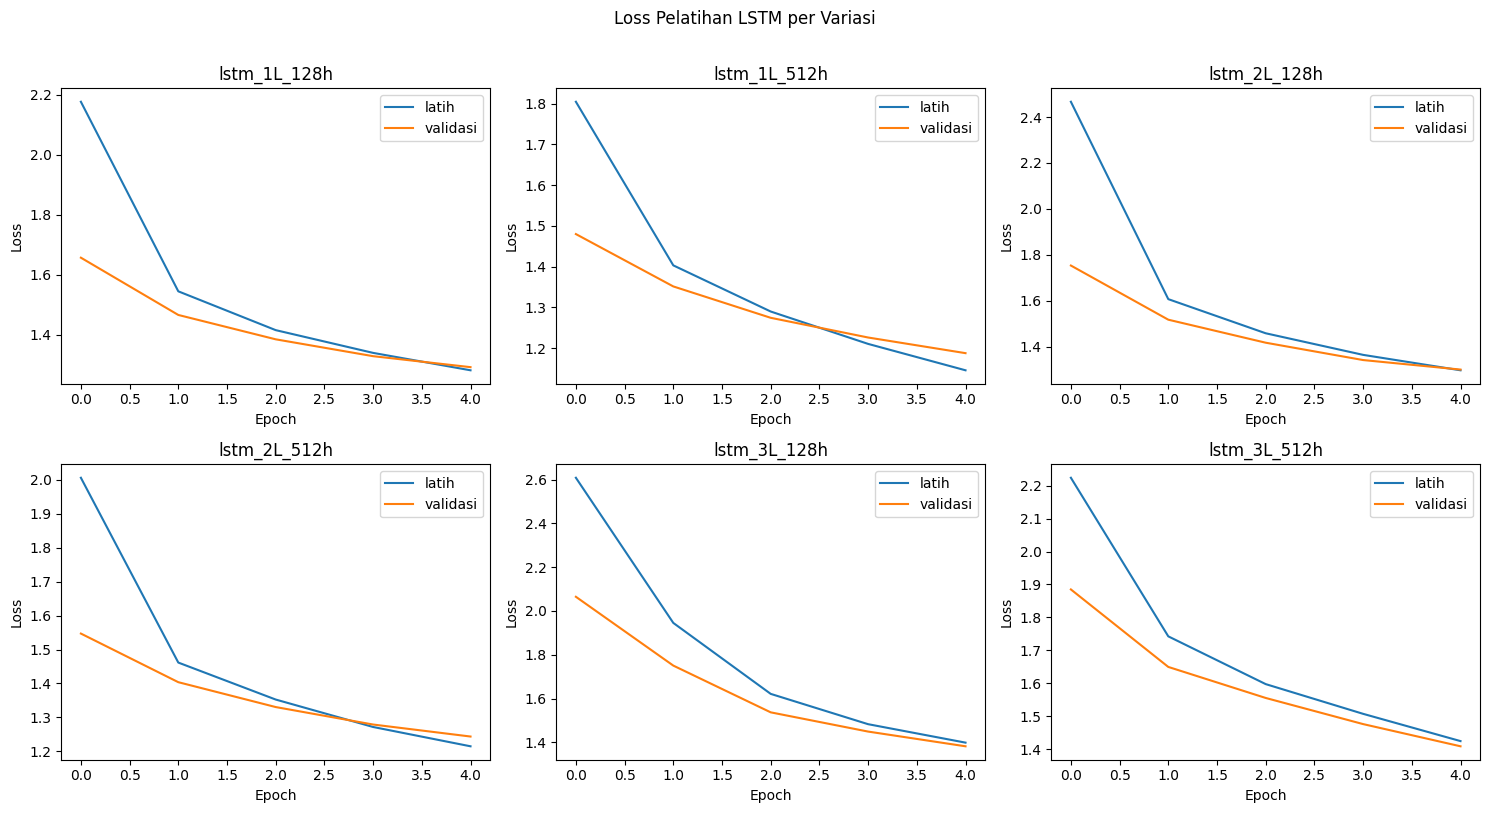

Model                  Val Loss Terbaik   Epoch
-----------------------------------------------
lstm_1L_128h                     1.2927       5
lstm_1L_512h                     1.1874       5
lstm_2L_128h                     1.2995       5
lstm_2L_512h                     1.2434       5
lstm_3L_128h                     1.3819       5
lstm_3L_512h                     1.4086       5

Model terbaik: lstm_1L_512h (layer=1, hidden=512)


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (name, hist) in zip(axes.flatten(), histories.items()):
    ax.plot(hist['loss'], label='latih')
    ax.plot(hist['val_loss'], label='validasi')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle("Loss Pelatihan LSTM per Variasi", y=1.01)
plt.tight_layout()
plt.savefig(weightsDir / "lstm_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Model':<22} {'Val Loss Terbaik':>16} {'Epoch':>7}")
print('-' * 47)
for name, hist in histories.items():
    print(f"{name:<22} {min(hist['val_loss']):>16.4f} {len(hist['val_loss']):>7}")

bestName = min(histories, key=lambda n: min(histories[n]['val_loss']))
bestLayers = int(bestName.split('L')[0].split('_')[1])
bestHidden = int(bestName.split('h')[0].split('_')[2])
print(f"\nModel terbaik: {bestName} (layer={bestLayers}, hidden={bestHidden})")


In [6]:
import importlib
import src.wajib.shared.decoder

# Reload modulnya
importlib.reload(src.wajib.shared.decoder)

# Re-import fungsinya agar yang ada di namespace notebook terupdate
from src.wajib.shared.decoder import greedyDecode

In [7]:
def loadScratchFromKeras(modelPath, numLayers):
    model = tf.keras.models.load_model(str(modelPath))

    embedLayer = EmbeddingLayer()
    embedLayer.loadWeights(model.get_layer('embedding'))

    projLayer = DenseLayer()
    projLayer.loadWeights(model.get_layer('cnn_proj'))

    outLayer = DenseLayer(activation='softmax')
    outLayer.loadWeights(model.get_layer('output'))

    lstmModel = LSTMScratch()
    lstmModel.loadWeights([model.get_layer(f'lstm_{i}') for i in range(numLayers)])

    return lstmModel, projLayer, embedLayer, outLayer

bestPath = weightsDir / f"{bestName}.keras"
lstmModel, projLayer, embedLayer, outLayer = loadScratchFromKeras(bestPath, bestLayers)

print("Contoh prediksi dari model LSTM terbaik:")
print("=" * 60)
for img in list(valCaps.keys())[:3]:
    feat = imageFeatures[img]
    caption = ' '.join(greedyDecode(lstmModel, projLayer, embedLayer, outLayer, feat, vocab))
    gt = valCaps[img][0]
    print(f"Ground truth : {gt}")
    print(f"Prediksi     : {caption}")
    print()


Contoh prediksi dari model LSTM terbaik:
Ground truth : a black dog leaps over a log
Prediksi     : a black dog is running through a grassy field

Ground truth : a man uses ice picks and crampons to scale ice
Prediksi     : a man in a red shirt is riding a bike on a ramp

Ground truth : a man and a baby are in a yellow kayak on water
Prediksi     : a man in a blue shirt is riding a skateboard on a skateboard



In [ ]:
results = {}

for numLayers, hiddenDim in variations:
    name = f"lstm_{numLayers}L_{hiddenDim}h"
    path = weightsDir / f"{name}.keras"
    lstmModel, projLayer, embedLayer, outLayer = loadScratchFromKeras(path, numLayers)

    bleuScores = []
    startTime = time.time()

    for img, caps in testCaps.items():
        if img not in imageFeatures:
            continue
        hyp = greedyDecode(lstmModel, projLayer, embedLayer, outLayer, imageFeatures[img], vocab, maxLen)
        refs = [cap.split() for cap in caps]
        bleuScores.append(sentence_bleu(refs, hyp, weights=(0.25, 0.25, 0.25, 0.25)))

    elapsed = time.time() - startTime
    results[name] = {
        'bleu4': np.mean(bleuScores),
        'time_s': elapsed,
        'layers': numLayers,
        'hidden': hiddenDim,
    }
    print(f"{name:<22}  BLEU-4={results[name]['bleu4']:.4f}  waktu={elapsed:.1f}s")


/home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU

lstm_1L_128h            BLEU-4=0.0290  waktu=112.1s
lstm_1L_512h            BLEU-4=0.0607  waktu=298.0s


In [ ]:
bestTestModel = max(results, key=lambda n: results[n]['bleu4'])

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
models = sorted(results.keys())
bleus = [results[m]['bleu4'] for m in models]
colors = ['red' if m == bestTestModel else 'blue' for m in models]

ax.bar(range(len(models)), bleus, color=colors)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('Skor BLEU-4')
ax.set_title('Skor BLEU-4 untuk Variasi LSTM di Data Uji')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(weightsDir / "lstm_bleu4_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print("Ringkasan BLEU-4 LSTM:")
print(f"{'='*60}")
print(f"{'Model':<22} {'BLEU-4':>10} {'Waktu (detik)':>14}")
print('-' * 50)
for model in sorted(results.keys(), key=lambda m: results[m]['bleu4'], reverse=True):
    print(f"{model:<22} {results[model]['bleu4']:>10.4f} {results[model]['time_s']:>14.1f}")

print(f"\nTerbaik (BLEU-4 data uji): {bestTestModel}")
print(f"  BLEU-4={results[bestTestModel]['bleu4']:.4f}")
